## Download Dataset

In [ ]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

file_id = '1jh3vSp9z5kIbmtGUmPZeGi_DYTofETuB'
downloaded = drive.CreateFile({'id': file_id})
downloaded.GetContentFile('dataset.csv')

print("Download complete!")

Download complete!


## Installs and Imports

In [ ]:
!pip install contractions wordcloud --quiet

In [ ]:
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
import nltk
import torch
import torch.nn as nn
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import Dataset, DataLoader

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Section 1: Data Understanding, Preprocessing, Tokenization and Padding

### Load and Explore the Dataset

In [ ]:
df = pd.read_csv('dataset.csv')
df.head()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [ ]:
df.shape

(28619, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB


In [ ]:
df = df[['is_sarcastic', 'headline']].reset_index(drop=True)
df['is_sarcastic'].value_counts()

,count
is_sarcastic,
0,14985
1,13634


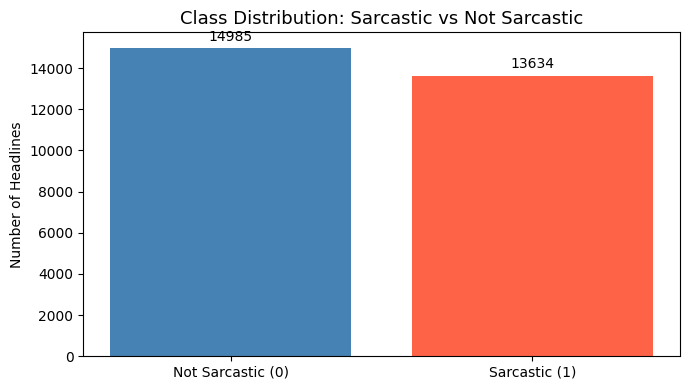

In [ ]:
# Class distribution bar chart
counts = df['is_sarcastic'].value_counts()
labels = ['Not Sarcastic (0)', 'Sarcastic (1)']
values = [counts[0], counts[1]]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, color=['steelblue', 'tomato'])
plt.bar_label(bars, padding=3)
plt.title('Class Distribution: Sarcastic vs Not Sarcastic', fontsize=13)
plt.ylabel('Number of Headlines')
plt.tight_layout()
plt.show()

### Text Cleaning and Preprocessing

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = contractions.fix(text)# expand contractions: don't -> do not
    text = re.sub(r'http\S+', '', text)# remove URLs
    text = re.sub(r'@\w+', '', text)# remove mentions
    text = re.sub(r'#\w+', '', text)# remove hashtags
    text = re.sub(r'\d+', '', text)# remove numbers
    text = re.sub(r'[^a-z\s]', '', text)# remove special characters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['cleaned'] = df['headline'].apply(clean_text)

print('Original 1 :', df['headline'][0])
print('Cleaned 1 :', df['cleaned'][0])
print()
print()
print('Original 2 :', df['headline'][1])
print('Cleaned 2 :', df['cleaned'][1])

Original 1 : thirtysomething scientists unveil doomsday clock of hair loss
Cleaned 1 : thirtysomething scientist unveil doomsday clock hair loss


Original 2 : dem rep. totally nails why congress is falling short on gender, racial equality
Cleaned 2 : dem rep totally nail congress falling short gender racial equality


### Visualize Cleaned Data

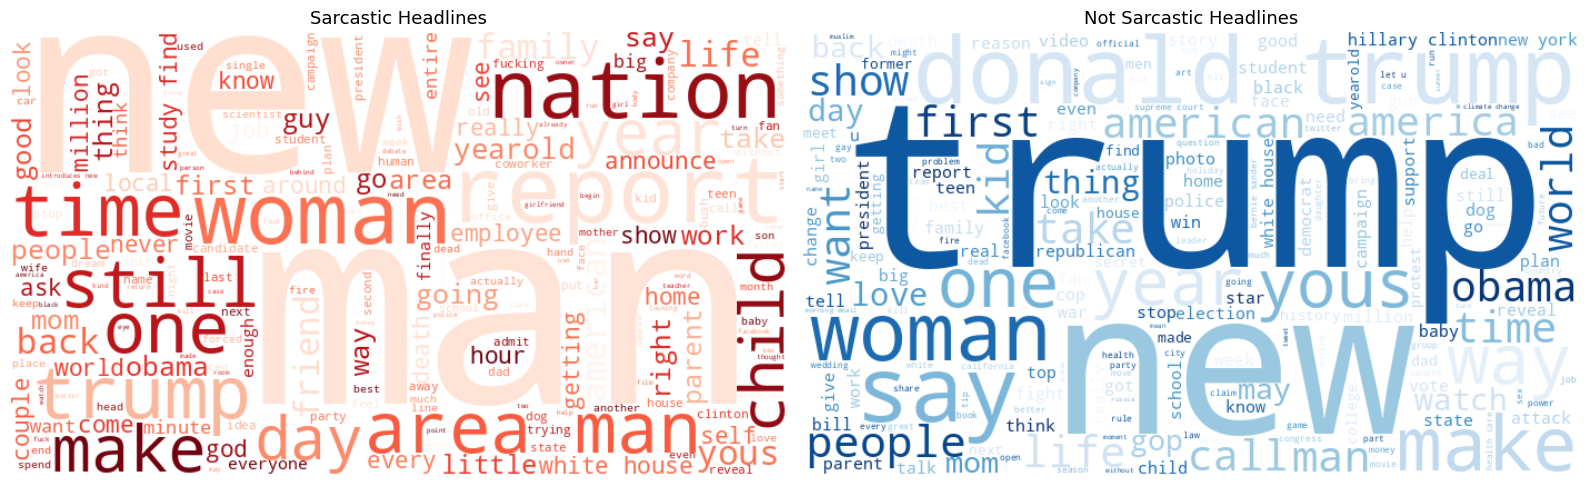

In [ ]:
# Word cloud
sarc_text = ' '.join(df[df['is_sarcastic'] == 1]['cleaned'])
not_sarc_text = ' '.join(df[df['is_sarcastic'] == 0]['cleaned'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_sarc = WordCloud(width=700, height=400, background_color='white', colormap='Reds').generate(sarc_text)
axes[0].imshow(wc_sarc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Sarcastic Headlines', fontsize=13)

wc_not = WordCloud(width=700, height=400, background_color='white', colormap='Blues').generate(not_sarc_text)
axes[1].imshow(wc_not, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Not Sarcastic Headlines', fontsize=13)

plt.tight_layout()
plt.show()

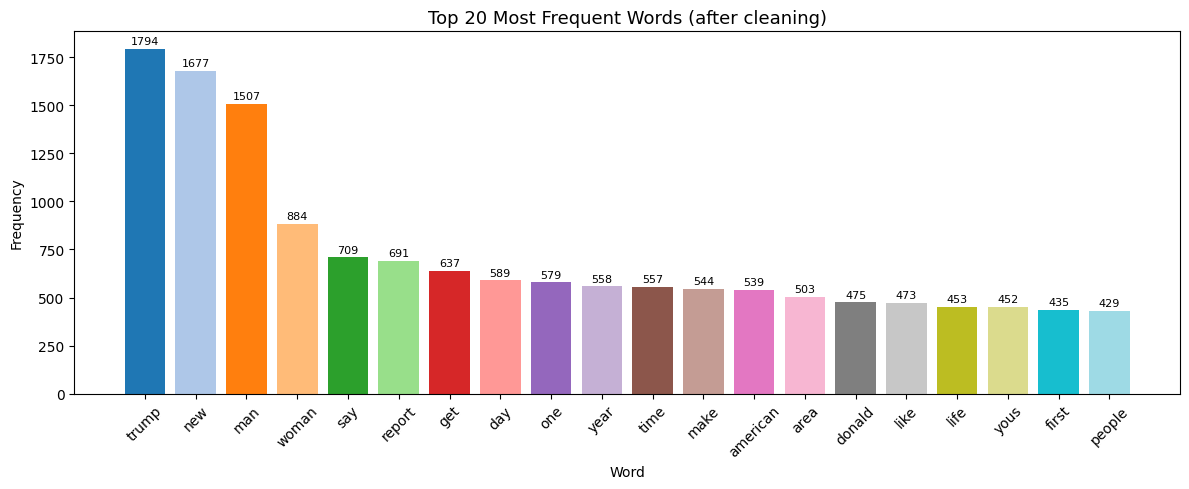

In [ ]:
# Top 20 most frequent words overall
all_words = ' '.join(df['cleaned']).split()
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)

plt.figure(figsize=(12, 5))
bars = plt.bar(words, freqs, color=plt.cm.tab20.colors[:20])
plt.bar_label(bars, padding=2, fontsize=8)
plt.title('Top 20 Most Frequent Words (after cleaning)', fontsize=13)
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Train/Test Split, Tokenization and Sequence Padding

In [ ]:
X = df['cleaned'].values
y = df['is_sarcastic'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train size:', len(X_train))
print('Test size :', len(X_test))

Train size: 22895
Test size : 5724


In [ ]:
# Build vocabulary from training data only so that no leakage hapens
vocab = {'<PAD>': 0, '<UNK>': 1}

for sentence in X_train:
    for token in sentence.split():
        if token not in vocab:
            vocab[token] = len(vocab)

vocab_size = len(vocab)
vocab_size

22525

95th percentile sequence length: 11


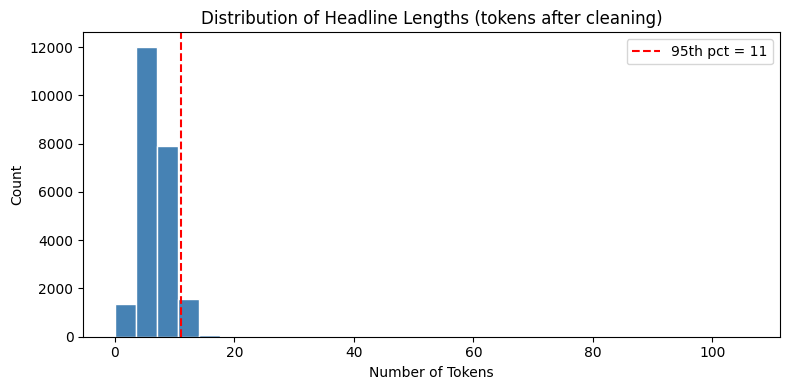

In [ ]:
# Percentile-based max length to avoid padding to outlier lengths
lengths = [len(s.split()) for s in X_train]
max_len = int(np.percentile(lengths, 95))
print(f'95th percentile sequence length: {max_len}')

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=30, color='steelblue', edgecolor='white')
plt.axvline(max_len, color='red', linestyle='--', label=f'95th pct = {max_len}')
plt.title('Distribution of Headline Lengths (tokens after cleaning)')
plt.xlabel('Number of Tokens')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

**Why did I do prepadding and not postpadding?**

Ans : Since we're using an RNN/LSTM that reads the sequence left to right and uses the final hidden state for classification, pre-padding puts the actual words right before that final step so the model's last hidden state captures real content rather than a string of zeros it just walked through after the meaningful tokens ended.

In [ ]:
def text_to_indices(sentence, vocab, max_len):
    tokens = sentence.split()[:max_len]
    indices = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    # Pre-padding with 0s
    padded = [0] * (max_len - len(indices)) + indices
    return padded

X_train_idx = np.array([text_to_indices(s, vocab, max_len) for s in X_train])
X_test_idx = np.array([text_to_indices(s, vocab, max_len) for s in X_test])

print('X_train_idx shape:', X_train_idx.shape)
print('X_test_idx shape :', X_test_idx.shape)

X_train_idx shape: (22895, 11)
X_test_idx shape : (5724, 11)


In [ ]:
class HeadlineDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = HeadlineDataset(X_train_idx, y_train)
test_dataset = HeadlineDataset(X_test_idx, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print('No. of Train batches:', len(train_loader))
print('No. of Test batches:', len(test_loader))

No. of Train batches: 358
No. of Test batches: 90


## Section 2: Model Building

### Training Utilities

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    # Set to training mode (enables dropout/batch norm)
    model.train()
    running_loss, correct = 0.0, 0

    for X_batch, y_batch in loader:
        # Send data to device
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass (flatten to match target shape)
        out = model(X_batch).squeeze(1)

        # Calculate loss
        loss = criterion(out, y_batch)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Track total loss
        running_loss += loss.item() * X_batch.size(0)

        # Convert logits to binary predictions
        preds = (torch.sigmoid(out) >= 0.5).long()

        # Count correct predictions
        correct += (preds == y_batch.long()).sum().item()

    return running_loss / len(loader.dataset), correct / len(loader.dataset)

In [ ]:
def evaluate(model, loader, criterion, device):
    # Set to evaluation mode (freezes dropout/batch norm)
    model.eval()
    running_loss, correct = 0.0, 0

    # Disable gradient calculation to save memory
    with torch.no_grad():
        for X_batch, y_batch in loader:
            # Send data to device
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            out = model(X_batch).squeeze(1)

            # Calculate loss
            loss = criterion(out, y_batch)

            # Track total loss
            running_loss += loss.item() * X_batch.size(0)

            # Convert logits to binary predictions
            preds = (torch.sigmoid(out) >= 0.5).long()

            # Count correct predictions
            correct += (preds == y_batch.long()).sum().item()

    return running_loss / len(loader.dataset), correct / len(loader.dataset)

In [ ]:
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, device, patience=5):
    # Initialize dictionary to store results
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    start = time.time()
    best_val_loss = float('inf')
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        # Run training phase
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)

        # Run validation phase
        vl, va = evaluate(model, test_loader, criterion, device)

        # Store results for plotting
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)

        print(f'Epoch {epoch:02d}/{epochs} train_loss: {tl:.4f} train_acc: {ta:.4f} val_loss: {vl:.4f} val_acc: {va:.4f}')

        # Check if validation loss improved
        if vl < best_val_loss:
            best_val_loss = vl
            # Save a copy of the best model weights
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            # Increment counter for early stopping
            bad_epochs += 1

        # Stop training if no improvement for 'patience' epochs
        if bad_epochs >= patience:
            print(f'Early stopping at epoch {epoch} (no improvement for {patience} epochs)')
            break

    # Calculate total duration
    elapsed = time.time() - start
    print(f'\nTotal training time: {elapsed:.1f}s')

    # Restore the best performing weights
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'Loaded best model with val_loss: {best_val_loss:.4f}')

    return history, elapsed

In [ ]:
def plot_history(history, title='Training History'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(epochs, history['train_loss'], label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], label='Val Acc')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_confusion_matrix(labels, preds, title='Confusion Matrix'):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Sarcastic', 'Sarcastic'],
                yticklabels=['Not Sarcastic', 'Sarcastic'])
    plt.title(title, fontsize=13)
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

In [ ]:
def get_all_preds(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            out = model(X_batch).squeeze(1)
            preds = (torch.sigmoid(out) >= 0.5).long().cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(y_batch.long().tolist())
    return all_labels, all_preds

### Model 1: Simple RNN with Trainable Embedding

In [ ]:
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x) # (batch, seq_len, embed_dim)
        _, hidden = self.rnn(embedded) # hidden: (1, batch, hidden_dim)
        hidden = self.dropout(hidden.squeeze(0)) # (batch, hidden_dim)
        out = self.fc(hidden) # (batch, 1)
        return out

rnn_model = SimpleRNNClassifier(vocab_size=vocab_size, embed_dim=100, hidden_dim=128).to(device)
print(rnn_model)
print(f'Total parameters: {sum(p.numel() for p in rnn_model.parameters()):,}')

SimpleRNNClassifier(
  (embedding): Embedding(22525, 100, padding_idx=0)
  (rnn): RNN(100, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Total parameters: 2,282,069


**Model 1 Training**

In [ ]:
criterion = nn.BCEWithLogitsLoss()
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=1e-3)

rnn_history, rnn_time = train_model(
    rnn_model, train_loader, test_loader,
    criterion, rnn_optimizer,
    epochs=20, device=device, patience=5
)

Epoch 01/20 train_loss: 0.6489 train_acc: 0.6155 val_loss: 0.6050 val_acc: 0.6763
Epoch 02/20 train_loss: 0.5323 train_acc: 0.7375 val_loss: 0.5416 val_acc: 0.7311
Epoch 03/20 train_loss: 0.4332 train_acc: 0.8045 val_loss: 0.5283 val_acc: 0.7453
Epoch 04/20 train_loss: 0.3429 train_acc: 0.8566 val_loss: 0.5416 val_acc: 0.7626
Epoch 05/20 train_loss: 0.2742 train_acc: 0.8914 val_loss: 0.5377 val_acc: 0.7725
Epoch 06/20 train_loss: 0.2148 train_acc: 0.9196 val_loss: 0.5990 val_acc: 0.7732
Epoch 07/20 train_loss: 0.1616 train_acc: 0.9436 val_loss: 0.6500 val_acc: 0.7629
Epoch 08/20 train_loss: 0.1156 train_acc: 0.9607 val_loss: 0.7983 val_acc: 0.7753
Early stopping at epoch 8 (no improvement for 5 epochs)

Total training time: 17.6s
Loaded best model with val_loss: 0.5283


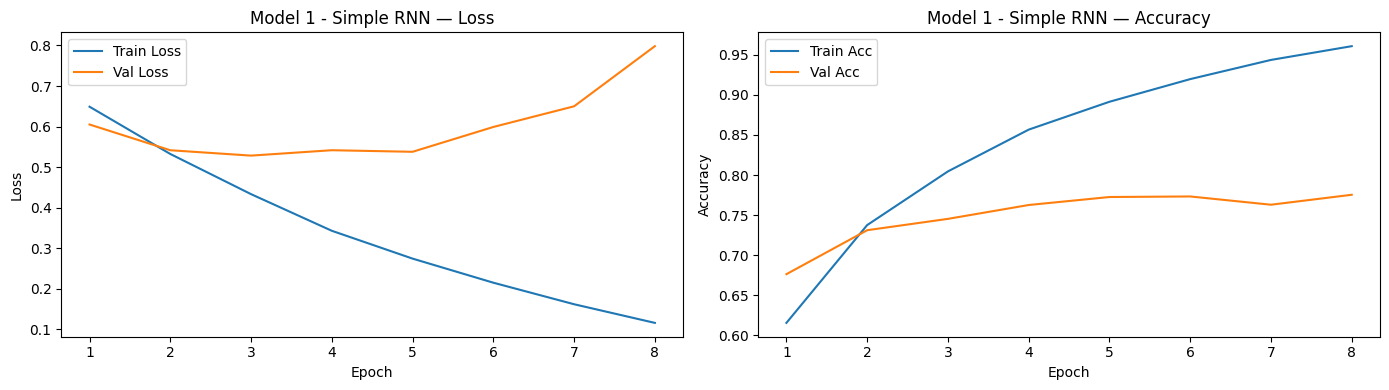

In [ ]:
plot_history(rnn_history, title='Model 1 - Simple RNN')

**Model 1 Evaluation**

Model 1 - Simple RNN - Test Accuracy: 0.7453

               precision    recall  f1-score   support

Not Sarcastic       0.77      0.73      0.75      2997
    Sarcastic       0.72      0.76      0.74      2727

     accuracy                           0.75      5724
    macro avg       0.75      0.75      0.75      5724
 weighted avg       0.75      0.75      0.75      5724



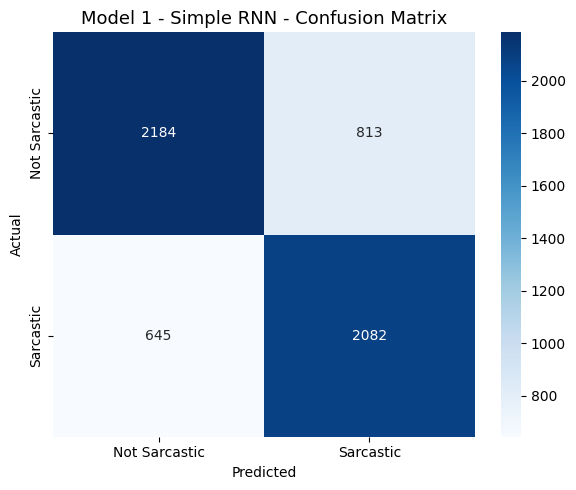

In [ ]:
rnn_labels, rnn_preds = get_all_preds(rnn_model, test_loader, device)
rnn_acc = accuracy_score(rnn_labels, rnn_preds)

print(f'Model 1 - Simple RNN - Test Accuracy: {rnn_acc:.4f}')
print()
print(classification_report(rnn_labels, rnn_preds, target_names=['Not Sarcastic', 'Sarcastic']))
plot_confusion_matrix(rnn_labels, rnn_preds, title='Model 1 - Simple RNN - Confusion Matrix')

### Model 2: LSTM with Trainable Embedding

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=0.3, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, 1)  # *2 because fwd + bwd hidden concat

    def forward(self, x):
        embedded = self.dropout(self.embedding(x)) # dropout on embeddings
        _, (hidden, _) = self.lstm(embedded) # hidden: (num_layers*2, batch, hidden_dim)
        hidden = self.dropout(torch.cat((hidden[-2], hidden[-1]), dim=1)) # concat last fwd + bwd
        out = self.fc(hidden)
        return out

lstm_model = LSTMClassifier(vocab_size=vocab_size, embed_dim=100, hidden_dim=128, num_layers=2).to(device)
print(lstm_model)
print(f'Total parameters: {sum(p.numel() for p in lstm_model.parameters()):,}')

LSTMClassifier(
  (embedding): Embedding(22525, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)
Total parameters: 2,883,541


**Model 2 Training**

In [ ]:
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

lstm_history, lstm_time = train_model(
    lstm_model, train_loader, test_loader,
    criterion, lstm_optimizer,
    epochs=20, device=device, patience=5
)

Epoch 01/20 train_loss: 0.6101 train_acc: 0.6547 val_loss: 0.5509 val_acc: 0.7151
Epoch 02/20 train_loss: 0.5074 train_acc: 0.7484 val_loss: 0.5032 val_acc: 0.7467
Epoch 03/20 train_loss: 0.4283 train_acc: 0.7984 val_loss: 0.4728 val_acc: 0.7739
Epoch 04/20 train_loss: 0.3671 train_acc: 0.8354 val_loss: 0.4939 val_acc: 0.7825
Epoch 05/20 train_loss: 0.3096 train_acc: 0.8656 val_loss: 0.4927 val_acc: 0.7900
Epoch 06/20 train_loss: 0.2679 train_acc: 0.8865 val_loss: 0.5035 val_acc: 0.7867
Epoch 07/20 train_loss: 0.2278 train_acc: 0.9064 val_loss: 0.5203 val_acc: 0.7897
Epoch 08/20 train_loss: 0.1973 train_acc: 0.9208 val_loss: 0.5544 val_acc: 0.7959
Early stopping at epoch 8 (no improvement for 5 epochs)

Total training time: 17.9s
Loaded best model with val_loss: 0.4728


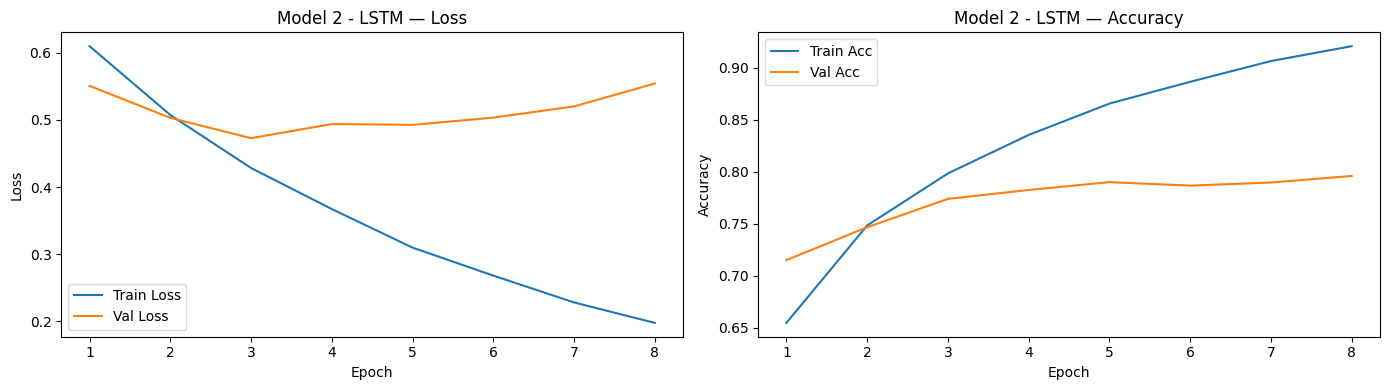

In [ ]:
plot_history(lstm_history, title='Model 2 - LSTM')

**Model 2 Evaluation**

Model 2 - LSTM - Test Accuracy: 0.7739

               precision    recall  f1-score   support

Not Sarcastic       0.77      0.81      0.79      2997
    Sarcastic       0.78      0.73      0.76      2727

     accuracy                           0.77      5724
    macro avg       0.77      0.77      0.77      5724
 weighted avg       0.77      0.77      0.77      5724



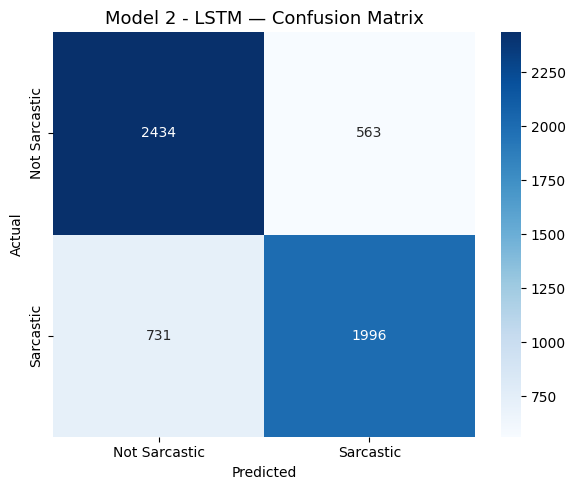

In [ ]:
lstm_labels, lstm_preds = get_all_preds(lstm_model, test_loader, device)
lstm_acc = accuracy_score(lstm_labels, lstm_preds)

print(f'Model 2 - LSTM - Test Accuracy: {lstm_acc:.4f}')
print()
print(classification_report(lstm_labels, lstm_preds, target_names=['Not Sarcastic', 'Sarcastic']))
plot_confusion_matrix(lstm_labels, lstm_preds, title='Model 2 - LSTM — Confusion Matrix')

### Model 3: LSTM with Pretrained GloVe Embeddings

In [ ]:
# 1. Uninstall the conflicting versions first
!pip uninstall -y numpy scipy gensim

# 2. Reinstall compatible versions together to resolve dependencies correctly
# Gensim 4.4.0 generally works best with NumPy < 2.0.0
!pip install "numpy<2.0.0" scipy --quiet
!pip install gensim --quiet

# 3. CRITICAL: Restart your runtime now if in Colab/Kaggle
# Then run this to verify:
import gensim
print(f"Gensim version: {gensim.__version__}")

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: gensim 4.4.0
Uninstalling gensim-4.4.0:
  Successfully uninstalled gensim-4.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires n

In [ ]:
import gensim.downloader as api

# Load GloVe 50-dim pretrained embeddings
glove_model = api.load('glove-wiki-gigaword-50')
embed_dim_glove = 50

print('GloVe model loaded. Vocab size:', len(glove_model))

GloVe model loaded. Vocab size: 400000


In [ ]:
# Build embedding matrix: rows = word indices, cols = GloVe vector
embedding_matrix = np.zeros((vocab_size, embed_dim_glove))

found = 0
for word, idx in vocab.items():
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        found += 1

# Explicitly zero out PAD and UNK so they contribute nothing to representation
embedding_matrix[vocab['<PAD>']] = np.zeros(embed_dim_glove)
embedding_matrix[vocab['<UNK>']] = np.zeros(embed_dim_glove)

print(f'Words found in GloVe: {found} / {vocab_size} ({100*found/vocab_size:.1f}%)')

Words found in GloVe: 19714 / 22525 (87.5%)


In [ ]:
class LSTMGloveClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, embedding_matrix, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = False # frozen
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=0.3, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, 1) # *2 bidirectional

    def forward(self, x):
        embedded = self.embedding(x) # frozen, no dropout on glove
        _, (hidden, _) = self.lstm(embedded)
        hidden = self.dropout(torch.cat((hidden[-2], hidden[-1]), dim=1))
        out = self.fc(hidden)
        return out

glove_model_clf = LSTMGloveClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim_glove,
    hidden_dim=128,
    embedding_matrix=embedding_matrix,
    num_layers=2
).to(device)

print(glove_model_clf)
trainable_params = sum(p.numel() for p in glove_model_clf.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in glove_model_clf.parameters())
print(f'Trainable parameters: {trainable_params:,} / Total: {total_params:,}')

LSTMGloveClassifier(
  (embedding): Embedding(22525, 50, padding_idx=0)
  (lstm): LSTM(50, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)
Trainable parameters: 579,841 / Total: 1,706,091


**Model 3 Training**

In [ ]:
# Only optimize non-frozen parameters
glove_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, glove_model_clf.parameters()), lr=1e-3
)

glove_history, glove_time = train_model(
    glove_model_clf, train_loader, test_loader,
    criterion, glove_optimizer,
    epochs=20, device=device, patience=5
)

Epoch 01/20 train_loss: 0.5681 train_acc: 0.7028 val_loss: 0.5322 val_acc: 0.7381
Epoch 02/20 train_loss: 0.4934 train_acc: 0.7602 val_loss: 0.4805 val_acc: 0.7734
Epoch 03/20 train_loss: 0.4472 train_acc: 0.7889 val_loss: 0.4649 val_acc: 0.7834
Epoch 04/20 train_loss: 0.4161 train_acc: 0.8062 val_loss: 0.4719 val_acc: 0.7741
Epoch 05/20 train_loss: 0.3877 train_acc: 0.8243 val_loss: 0.4628 val_acc: 0.7888
Epoch 06/20 train_loss: 0.3555 train_acc: 0.8404 val_loss: 0.4691 val_acc: 0.7916
Epoch 07/20 train_loss: 0.3234 train_acc: 0.8578 val_loss: 0.4678 val_acc: 0.7904
Epoch 08/20 train_loss: 0.2842 train_acc: 0.8809 val_loss: 0.4804 val_acc: 0.7919
Epoch 09/20 train_loss: 0.2474 train_acc: 0.8957 val_loss: 0.5080 val_acc: 0.7855
Epoch 10/20 train_loss: 0.2069 train_acc: 0.9150 val_loss: 0.5360 val_acc: 0.7905
Early stopping at epoch 10 (no improvement for 5 epochs)

Total training time: 32.6s
Loaded best model with val_loss: 0.4628


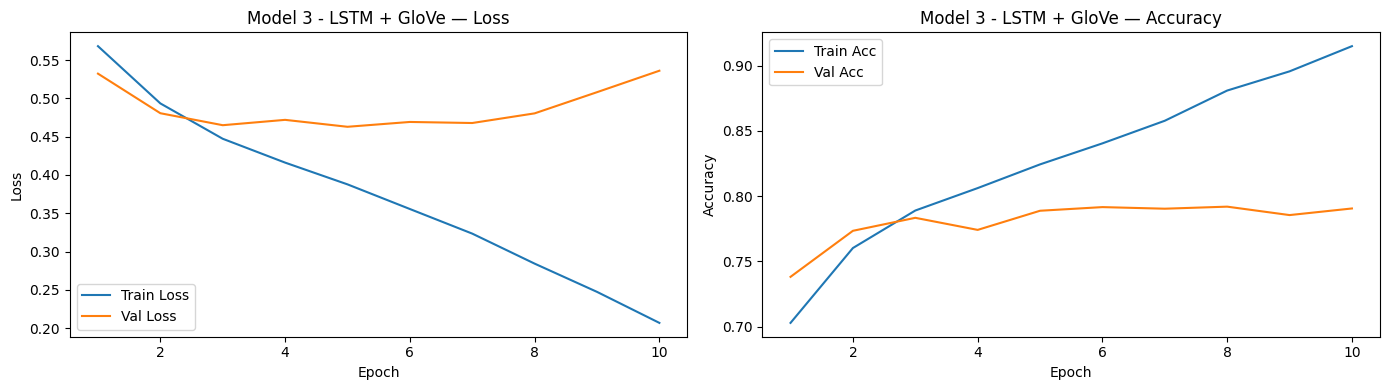

In [ ]:
plot_history(glove_history, title='Model 3 - LSTM + GloVe')

**Model 3 Evaluation**

Model 3 - LSTM + GloVe - Test Accuracy: 0.7888

               precision    recall  f1-score   support

Not Sarcastic       0.83      0.75      0.79      2997
    Sarcastic       0.75      0.83      0.79      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



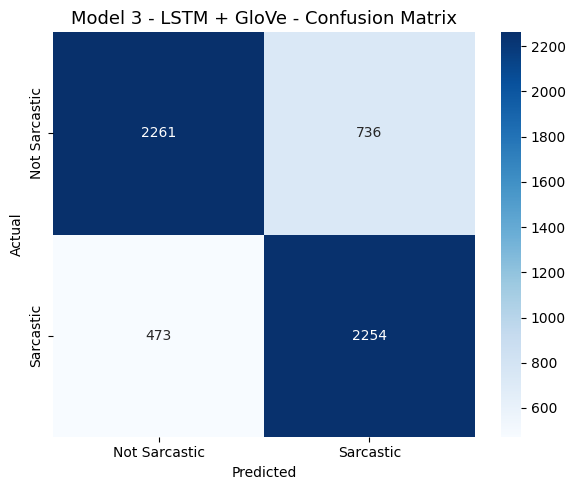

In [ ]:
glove_labels, glove_preds = get_all_preds(glove_model_clf, test_loader, device)
glove_acc = accuracy_score(glove_labels, glove_preds)

print(f'Model 3 - LSTM + GloVe - Test Accuracy: {glove_acc:.4f}')
print()
print(classification_report(glove_labels, glove_preds, target_names=['Not Sarcastic', 'Sarcastic']))
plot_confusion_matrix(glove_labels, glove_preds, title='Model 3 - LSTM + GloVe - Confusion Matrix')

## Section 3: Comparative Analysis

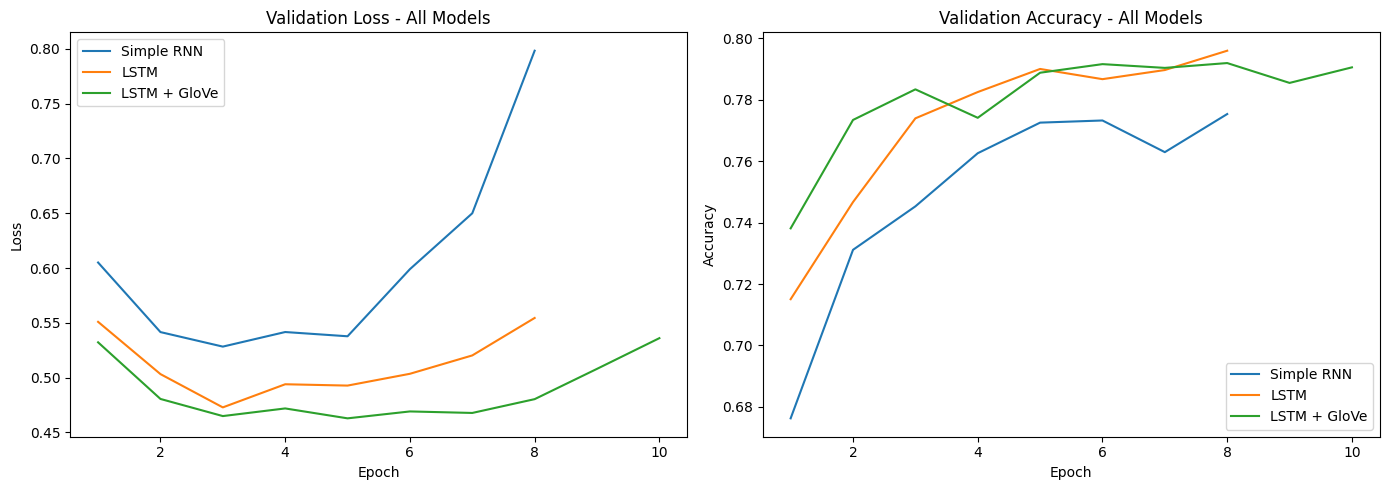

In [ ]:
# Side-by-side loss curves for all three models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, label in [
    (rnn_history, 'Simple RNN'),
    (lstm_history, 'LSTM'),
    (glove_history, 'LSTM + GloVe')
]:
    e = range(1, len(hist['val_loss']) + 1)
    axes[0].plot(e, hist['val_loss'], label=label)
    axes[1].plot(e, hist['val_acc'], label=label)

axes[0].set_title('Validation Loss - All Models'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].set_title('Validation Accuracy - All Models'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
print(f"{'Model':<30}{'Test Acc':<12}{'Train Time (s)':<18}")
print('-' * 60)
print(f"{'Simple RNN':<30}{rnn_acc:<12.4f}{rnn_time:<18.1f}")
print(f"{'LSTM':<30}{lstm_acc:<12.4f}{lstm_time:<18.1f}")
print(f"{'LSTM + GloVe':<30}{glove_acc:<12.4f}{glove_time:<18.1f}")

Model                         Test Acc    Train Time (s)    
------------------------------------------------------------
Simple RNN                    0.7453      17.6              
LSTM                          0.7739      17.9              
LSTM + GloVe                  0.7888      32.6              


## Section 4: Error Analysis

In [ ]:
# Using the best model (LSTM + GloVe) for error analysis
# Find ingmisclassified examples by matching predictions back to original headlines

# Rebuild test indices aligned to original text
test_indices = np.where(np.isin(np.arange(len(df)),
    train_test_split(np.arange(len(df)), test_size=0.2, random_state=42, stratify=y)[1]))[0]

# Collect misclassified samples
misclassified = []
for i, (true, pred) in enumerate(zip(glove_labels, glove_preds)):
    if true != pred:
        orig_idx = test_indices[i]
        misclassified.append({
            'headline': df['headline'].iloc[orig_idx],
            'true_label': true,
            'predicted': pred
        })

print(f'Total misclassified: {len(misclassified)} / {len(glove_labels)}')
print()

Total misclassified: 1209 / 5724



In [ ]:
# Display 3 misclassified examples
for i, sample in enumerate(misclassified[:3]):
    label_map = {0: 'Not Sarcastic', 1: 'Sarcastic'}
    print(f'Example {i+1}')
    print(f'Headline: {sample["headline"]}')
    print(f'True Label: {label_map[sample["true_label"]]}')
    print(f'Predicted: {label_map[sample["predicted"]]}')
    print()

Example 1
Headline: shadow government getting too large to meet in marriott conference room b
True Label: Sarcastic
Predicted: Not Sarcastic

Example 2
Headline: lots of parents know this scenario
True Label: Not Sarcastic
Predicted: Sarcastic

Example 3
Headline: this lesbian is considered a father in indiana (and an amazing one at that)
True Label: Sarcastic
Predicted: Not Sarcastic



In [ ]:
# False Positive vs False Negative breakdown
fp = sum(1 for t, p in zip(glove_labels, glove_preds) if t == 0 and p == 1)  # predicted sarcastic, actually not
fn = sum(1 for t, p in zip(glove_labels, glove_preds) if t == 1 and p == 0)  # predicted not sarcastic, actually is

print(f'False Positives (predicted Sarcastic, actually Not): {fp}')
print(f'False Negatives (predicted Not Sarcastic, actually Sarcastic): {fn}')

False Positives (predicted Sarcastic, actually Not): 736
False Negatives (predicted Not Sarcastic, actually Sarcastic): 473
